# 09 — LoRA Inference: Config F

**Config F = SD Inpainting + LoRA(r=8) + ControlNet-Canny**  
Future work — kết hợp domain adaptation (LoRA) với shape prior (ControlNet).

```
Ablation chain:
  A: SD only
  B: SD + ControlNet
  C: SD + ControlNet + IP-Adapter
  E: SD + LoRA               ← alternative
  F: SD + LoRA + CN          ← BẠN Ở ĐÂY (future work)
  G: SD + LoRA + CN + IP     ← future work
```

```
project_root/
├── data/synthetic_occ/           ← output từ notebook 01
├── outputs/
│   ├── eval/                     ← từ notebook 05
│   ├── lora_weights/r8/best/     ← từ notebook 07
│   └── lora_sd_cn/               ← Config F output
│       ├── x_hat/
│       ├── eval_gt_200/
│       ├── eval_pred_200/
│       └── reports/
```

**Chạy sau:** notebook 07  
**Chạy trước:** re-run notebook 05 → 06

In [1]:
# CELL 1 — Dependencies
import sys
!{sys.executable} -m pip install -q \
    "diffusers>=0.27.0" "peft>=0.8.0" "accelerate>=0.26.0" \
    "transformers>=4.36.0" scikit-image lpips clean-fid opencv-python
print("Dependencies ready")

Dependencies ready


In [2]:
# CELL 2 — Config & Paths
import random, json, time
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import cv2
from PIL import Image

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

PROJECT_ROOT = Path(".").resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

SYNTH_DIR = PROJECT_ROOT / "data" / "synthetic_occ"
GT_DIR    = SYNTH_DIR / "x_gt"
OCC_DIR   = SYNTH_DIR / "x_occ"
MASK_DIR  = SYNTH_DIR / "masks"
META_CSV  = SYNTH_DIR / "metadata_synthetic_occ.csv"
EVAL_CSV  = PROJECT_ROOT / "outputs" / "eval" / "metrics_per_image_A_SD_only.csv"

LORA_WEIGHTS = PROJECT_ROOT / "outputs" / "lora_weights" / "r8" / "best"
TRAIN_CFG    = PROJECT_ROOT / "outputs" / "lora_weights" / "r8" / "training_config.json"

SD_MODEL_ID = "runwayml/stable-diffusion-inpainting"
CN_MODEL_ID = "lllyasviel/control_v11p_sd15_canny"

# Output dir Config F
LORA_SD_CN_DIR = PROJECT_ROOT / "outputs" / "lora_sd_cn"
PRED_DIR       = LORA_SD_CN_DIR / "x_hat"
EVAL_GT_DIR    = LORA_SD_CN_DIR / "eval_gt_200"
EVAL_PRED_DIR  = LORA_SD_CN_DIR / "eval_pred_200"
REPORT_DIR     = LORA_SD_CN_DIR / "reports"
for d in [PRED_DIR, EVAL_GT_DIR, EVAL_PRED_DIR, REPORT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Dirs so sánh chart
XHAT_A = PROJECT_ROOT / "outputs" / "baseline_sd2"      / "x_hat"
XHAT_B = PROJECT_ROOT / "outputs" / "controlnet_sd"     / "x_hat"
XHAT_E = PROJECT_ROOT / "outputs" / "lora_sd"           / "x_hat"

PROMPT         = "a car, realistic, high quality, detailed"
NEG_PROMPT     = "blurry, distorted, artifacts"
NUM_STEPS      = 20
GUIDANCE       = 7.5
TEST_SIZE      = 200
CANNY_LOW      = 80
CANNY_HIGH     = 150
MASK_DILATE_PX = 5
CN_SCALE_GRID  = [0.25, 0.40, 0.55, 0.65]
GRID_SAMPLE    = 15

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE  = torch.float16 if DEVICE == "cuda" else torch.float32

assert SYNTH_DIR.exists(), f"Dataset không tìm thấy: {SYNTH_DIR}"
if not LORA_WEIGHTS.exists():
    raise FileNotFoundError(f"LoRA weights không tìm thấy: {LORA_WEIGHTS}\n→ Chạy 07 trước!")

train_cfg = json.loads(TRAIN_CFG.read_text()) if TRAIN_CFG.exists() else {}
lora_rank = train_cfg.get("lora_rank", 8)
meta      = pd.read_csv(META_CSV)
meta.columns = meta.columns.str.strip().str.lower()

print(f"Device       : {DEVICE}")
print(f"Project root : {PROJECT_ROOT}")
print(f"LoRA weights : {LORA_WEIGHTS}  (r={lora_rank}, best_val={train_cfg.get('best_val_loss','N/A')})")
print(f"Output       : {LORA_SD_CN_DIR}")
print(f"Config F     : SD + LoRA(r={lora_rank}) + ControlNet-Canny")
print(f"Metadata     : {len(meta):,} rows")

Device       : cuda
Project root : D:\CS331\DoAn\Occluded-Object-Restoration-CarsFocus
LoRA weights : D:\CS331\DoAn\Occluded-Object-Restoration-CarsFocus\outputs\lora_weights\r8\best  (r=8, best_val=0.011640875253360718)
Output       : D:\CS331\DoAn\Occluded-Object-Restoration-CarsFocus\outputs\lora_sd_cn
Config F     : SD + LoRA(r=8) + ControlNet-Canny
Metadata     : 11,254 rows


In [3]:
# CELL 3 — Load Pipeline Config F
# SD Inpainting + LoRA(r=8) fused + ControlNet-Canny
# Không IP-Adapter, không xformers
from diffusers import (
    StableDiffusionControlNetInpaintPipeline,
    ControlNetModel,
    DPMSolverMultistepScheduler,
)
from peft import PeftModel

print("Loading ControlNet...")
controlnet = ControlNetModel.from_pretrained(CN_MODEL_ID, torch_dtype=DTYPE)

print("Loading SD Inpainting + ControlNet pipeline...")
pipe = StableDiffusionControlNetInpaintPipeline.from_pretrained(
    SD_MODEL_ID, controlnet=controlnet,
    torch_dtype=DTYPE, safety_checker=None, requires_safety_checker=False,
)
pipe.scheduler = DPMSolverMultistepScheduler.from_config(pipe.scheduler.config)

print(f"Loading & fusing LoRA r={lora_rank}...")
pipe.unet = PeftModel.from_pretrained(pipe.unet, str(LORA_WEIGHTS))
pipe.unet = pipe.unet.merge_and_unload()
print("LoRA fused.")

pipe = pipe.to(DEVICE)
pipe.enable_attention_slicing("auto")
pipe.vae.enable_slicing()

print(f"\nPipeline ready — Config F")
print(f"  SD + LoRA(r={lora_rank}) + ControlNet-Canny")
print(f"  IP-Adapter  : False")
print(f"  Scheduler   : {pipe.scheduler.__class__.__name__}")

c:\Users\Admin\anaconda3\envs\lora_311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading ControlNet...


'(ReadTimeoutError("HTTPSConnectionPool(host='huggingface.co', port=443): Read timed out. (read timeout=10)"), '(Request ID: bd98efcc-24a4-48c6-899f-4c2e2ee11957)')' thrown while requesting HEAD https://huggingface.co/lllyasviel/control_v11p_sd15_canny/resolve/main/config.json
Retrying in 1s [Retry 1/5].
'(ReadTimeoutError("HTTPSConnectionPool(host='huggingface.co', port=443): Read timed out. (read timeout=10)"), '(Request ID: 0a3fe1f3-dafb-4510-b9ea-4649a95961ea)')' thrown while requesting HEAD https://huggingface.co/lllyasviel/control_v11p_sd15_canny/resolve/main/config.json
Retrying in 2s [Retry 2/5].
'(ReadTimeoutError("HTTPSConnectionPool(host='huggingface.co', port=443): Read timed out. (read timeout=10)"), '(Request ID: 092970d1-eb16-40db-8048-a74f575990d8)')' thrown while requesting HEAD https://huggingface.co/lllyasviel/control_v11p_sd15_canny/resolve/main/config.json
Retrying in 4s [Retry 3/5].


Loading SD Inpainting + ControlNet pipeline...


'(ReadTimeoutError("HTTPSConnectionPool(host='huggingface.co', port=443): Read timed out. (read timeout=10)"), '(Request ID: 33d98951-367d-4bde-b528-69f62d58ba9a)')' thrown while requesting HEAD https://huggingface.co/runwayml/stable-diffusion-inpainting/resolve/main/model_index.json
Retrying in 1s [Retry 1/5].
'(ReadTimeoutError("HTTPSConnectionPool(host='huggingface.co', port=443): Read timed out. (read timeout=10)"), '(Request ID: 3d3ae8cf-ce65-4101-b9ec-4d5a79b16257)')' thrown while requesting HEAD https://huggingface.co/stable-diffusion-v1-5/stable-diffusion-inpainting/resolve/main/model_index.json
Retrying in 1s [Retry 1/5].
'(ReadTimeoutError("HTTPSConnectionPool(host='huggingface.co', port=443): Read timed out. (read timeout=10)"), '(Request ID: 203366f7-94eb-4eda-843e-182c4d3da8d1)')' thrown while requesting HEAD https://huggingface.co/stable-diffusion-v1-5/stable-diffusion-inpainting/resolve/main/model_index.json
Retrying in 2s [Retry 2/5].
'(ReadTimeoutError("HTTPSConnection

Loading & fusing LoRA r=8...
LoRA fused.

Pipeline ready — Config F
  SD + LoRA(r=8) + ControlNet-Canny
  IP-Adapter  : False
  Scheduler   : DPMSolverMultistepScheduler


In [4]:
# CELL 4 — Helper Functions
from skimage.metrics import structural_similarity as ssim_fn
import lpips as lpips_lib

lpips_model = lpips_lib.LPIPS(net="alex").to(DEVICE).eval()


def extract_canny_masked(image_pil, mask_pil,
                         low=CANNY_LOW, high=CANNY_HIGH, dilate_px=MASK_DILATE_PX):
    img   = np.array(image_pil.convert("RGB"))
    edges = cv2.Canny(cv2.cvtColor(img, cv2.COLOR_RGB2GRAY), low, high)
    msk   = np.array(mask_pil.convert("L"))
    if dilate_px > 0:
        k   = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (dilate_px*2+1, dilate_px*2+1))
        msk = cv2.dilate(msk, k, iterations=1)
    edges[msk > 127] = 0
    return Image.fromarray(np.stack([edges]*3, axis=2))


def masked_ssim(gt, pred, m):
    _, smap = ssim_fn(gt/255., pred/255., channel_axis=2, data_range=1.0, full=True)
    return float(smap[m.astype(bool)].mean()) if m.sum() > 0 else float(smap.mean())


def masked_lpips(gt, pred, m):
    mf   = m.astype(np.float32)[..., None]
    gt_t = torch.from_numpy((gt*mf).astype(np.uint8)).permute(2,0,1).unsqueeze(0).float()/127.5-1.
    pr_t = torch.from_numpy((pred*mf).astype(np.uint8)).permute(2,0,1).unsqueeze(0).float()/127.5-1.
    with torch.no_grad():
        return float(lpips_model(gt_t.to(DEVICE), pr_t.to(DEVICE)).item())


def inpaint_f(image, mask, prompt, cn_scale=0.4, seed=SEED):
    """Config F: LoRA(fused) + ControlNet-Canny (mask-aware), không IP-Adapter."""
    canny = extract_canny_masked(image, mask)
    gen   = torch.Generator(device=DEVICE).manual_seed(seed)
    if DEVICE == "cuda":
        with torch.autocast("cuda"):
            out = pipe(
                prompt=prompt, negative_prompt=NEG_PROMPT,
                image=image, control_image=canny, mask_image=mask,
                num_inference_steps=NUM_STEPS, guidance_scale=GUIDANCE,
                controlnet_conditioning_scale=cn_scale, generator=gen,
            ).images[0]
    else:
        out = pipe(
            prompt=prompt, negative_prompt=NEG_PROMPT,
            image=image, control_image=canny, mask_image=mask,
            num_inference_steps=NUM_STEPS, guidance_scale=GUIDANCE,
            controlnet_conditioning_scale=cn_scale, generator=gen,
        ).images[0]
    return out


print("Helper functions defined.")

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


c:\Users\Admin\anaconda3\envs\lora_311\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Admin\anaconda3\envs\lora_311\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: c:\Users\Admin\anaconda3\envs\lora_311\Lib\site-packages\lpips\weights\v0.1\alex.pth
Helper functions defined.


c:\Users\Admin\anaconda3\envs\lora_311\Lib\site-packages\lpips\lpips.py:107: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.load_state_dict(torch.load(model_path, map_lo

In [5]:
# CELL 5 — Grid Search cn_scale  (non-test pool)
from tqdm.auto import tqdm

if EVAL_CSV.exists():
    test_stems = set(pd.read_csv(EVAL_CSV)["stem"].tolist())
else:
    test_stems = set(meta.sample(TEST_SIZE, random_state=SEED)["stem"].tolist())
    print("⚠  eval CSV không tìm thấy — reproduced test split")

non_test  = meta[~meta["stem"].isin(test_stems)].reset_index(drop=True)
grid_pool = non_test.sample(min(GRID_SAMPLE, len(non_test)), random_state=SEED).reset_index(drop=True)
print(f"Grid search: {len(CN_SCALE_GRID)} scales × {len(grid_pool)} ảnh")

grid_res = []
for scale in CN_SCALE_GRID:
    ss, lp = [], []
    for _, r in tqdm(grid_pool.iterrows(), total=len(grid_pool),
                     desc=f"cn={scale:.2f}", leave=False):
        occ  = Image.open(OCC_DIR  / r["x_occ"]).convert("RGB").resize((512,512))
        msk  = Image.open(MASK_DIR / f"{r['stem']}.png").convert("L").resize((512,512))
        gt   = Image.open(GT_DIR   / r["x_gt"]).convert("RGB").resize((512,512))
        pred = inpaint_f(occ, msk, PROMPT, cn_scale=scale)
        mk01 = (cv2.resize(
            cv2.imread(str(MASK_DIR/f"{r['stem']}.png"), cv2.IMREAD_GRAYSCALE),
            (512,512)) > 127).astype(np.uint8)
        ss.append(masked_ssim(np.array(gt), np.array(pred), mk01))
        lp.append(masked_lpips(np.array(gt), np.array(pred), mk01))
    grid_res.append({"cn_scale": scale,
                     "ssim_mean": float(np.mean(ss)),
                     "lpips_mean": float(np.mean(lp))})
    print(f"  cn={scale:.2f}  SSIM={np.mean(ss):.4f}  LPIPS={np.mean(lp):.4f}")

grid_df  = pd.DataFrame(grid_res)
BEST_CN  = float(grid_df.loc[grid_df["lpips_mean"].idxmin(), "cn_scale"])
grid_df.to_csv(REPORT_DIR / "grid_search.csv", index=False)
print(f"\nBest cn_scale: {BEST_CN}")
print(grid_df.to_string(index=False))

⚠  eval CSV không tìm thấy — reproduced test split
Grid search: 4 scales × 15 ảnh


100%|██████████| 20/20 [00:06<00:00,  3.07it/s]7.05s/it]


  cn=0.25  SSIM=0.6106  LPIPS=0.0515


100%|██████████| 20/20 [00:06<00:00,  3.07it/s]7.03s/it]


  cn=0.40  SSIM=0.6120  LPIPS=0.0518


100%|██████████| 20/20 [00:06<00:00,  3.07it/s]7.03s/it]


  cn=0.55  SSIM=0.6097  LPIPS=0.0530


100%|██████████| 20/20 [00:06<00:00,  3.07it/s]7.04s/it]
                                                        

  cn=0.65  SSIM=0.6096  LPIPS=0.0532

Best cn_scale: 0.25
 cn_scale  ssim_mean  lpips_mean
     0.25   0.610584    0.051518
     0.40   0.612046    0.051848
     0.55   0.609687    0.052990
     0.65   0.609602    0.053223


In [6]:
# CELL 6 — Full Inference 200 ảnh
test_df = meta.sample(TEST_SIZE, random_state=SEED).reset_index(drop=True)
print(f"Test set: {len(test_df)} ảnh | cn_scale={BEST_CN}")

pred_records = []
t0 = time.time()

for idx, r in tqdm(test_df.iterrows(), total=len(test_df), desc="Config F inference"):
    occ  = Image.open(OCC_DIR  / r["x_occ"]).convert("RGB").resize((512,512))
    msk  = Image.open(MASK_DIR / f"{r['stem']}.png").convert("L").resize((512,512))
    gt   = Image.open(GT_DIR   / r["x_gt"]).convert("RGB").resize((512,512))
    pred = inpaint_f(occ, msk, PROMPT, cn_scale=BEST_CN)
    name = f"{r['stem']}.png"
    pred.save(PRED_DIR / name)
    gt.save(EVAL_GT_DIR / name)
    pred.save(EVAL_PRED_DIR / name)
    pred_records.append({
        "stem": r["stem"], "x_gt": r["x_gt"], "x_occ": r["x_occ"],
        "occlusion_ratio": r["occlusion_ratio"], "pred": name,
    })

infer_elapsed = time.time() - t0
pred_df = pd.DataFrame(pred_records)
print(f"Inference done: {len(pred_df)} ảnh trong {infer_elapsed/60:.1f} min")

Test set: 200 ảnh | cn_scale=0.25


Config F inference: 100%|██████████| 200/200 [23:18<00:00,  6.99s/it]

Inference done: 200 ảnh trong 23.3 min


In [7]:
# CELL 7 — Metrics (SSIM / LPIPS / FID)
from cleanfid import fid

metric_rows = []
for _, r in tqdm(pred_df.iterrows(), total=len(pred_df), desc="Metrics"):
    gt   = cv2.cvtColor(cv2.imread(str(GT_DIR   / r["x_gt"])),  cv2.COLOR_BGR2RGB)
    pr   = cv2.cvtColor(cv2.imread(str(PRED_DIR / r["pred"])), cv2.COLOR_BGR2RGB)
    gt   = cv2.resize(gt, (512,512)); pr = cv2.resize(pr, (512,512))
    mk01 = (cv2.resize(
        cv2.imread(str(MASK_DIR/f"{r['stem']}.png"), cv2.IMREAD_GRAYSCALE),
        (512,512)) > 127).astype(np.uint8)
    metric_rows.append({
        "stem": r["stem"], "occlusion_ratio": r["occlusion_ratio"],
        "ssim": masked_ssim(gt, pr, mk01), "lpips": masked_lpips(gt, pr, mk01),
    })

metric_df = pd.DataFrame(metric_rows)
print("Computing FID...")
fid_value = fid.compute_fid(str(EVAL_GT_DIR), str(EVAL_PRED_DIR), mode="clean", num_workers=0)

summary = {
    "config"             : "F_LoRA_CN",
    "model"              : f"{SD_MODEL_ID} + LoRA(r={lora_rank}) + {CN_MODEL_ID}",
    "scheduler"          : pipe.scheduler.__class__.__name__,
    "num_test_images"    : int(len(metric_df)),
    "steps"              : int(NUM_STEPS), "guidance": float(GUIDANCE),
    "cn_scale"           : float(BEST_CN), "ip_scale": None,
    "lora_rank"          : int(lora_rank),
    "lora_best_val_loss" : float(train_cfg.get("best_val_loss", 0)),
    "use_controlnet"     : True, "use_ip_adapter": False,
    "ssim_mean"          : float(metric_df["ssim"].mean()),
    "lpips_mean"         : float(metric_df["lpips"].mean()),
    "fid"                : float(fid_value),
    "inference_minutes"  : float(infer_elapsed / 60),
    "xformers": False, "attention_slicing": True,
}

metric_df.to_csv(REPORT_DIR / "F_LoRA_CN_metrics_per_image.csv", index=False)
pd.DataFrame([summary]).to_csv(REPORT_DIR / "F_LoRA_CN_summary.csv", index=False)

print("=" * 55)
print(f"Config F (SD + LoRA r={lora_rank} + ControlNet-Canny):")
print(f"  SSIM  mean : {summary['ssim_mean']:.4f}")
print(f"  LPIPS mean : {summary['lpips_mean']:.4f}")
print(f"  FID        : {summary['fid']:.2f}")
print(f"  cn_scale   : {BEST_CN}")
print("=" * 55)

Metrics: 100%|██████████| 200/200 [00:35<00:00,  5.57it/s]


Computing FID...
compute FID between two folders
Found 400 images in the folder D:\CS331\DoAn\Occluded-Object-Restoration-CarsFocus\outputs\lora_sd_cn\eval_gt_200


FID eval_gt_200 : 100%|██████████| 13/13 [00:13<00:00,  1.03s/it]


Found 400 images in the folder D:\CS331\DoAn\Occluded-Object-Restoration-CarsFocus\outputs\lora_sd_cn\eval_pred_200


FID eval_pred_200 : 100%|██████████| 13/13 [00:12<00:00,  1.01it/s]


Config F (SD + LoRA r=8 + ControlNet-Canny):
  SSIM  mean : 0.5955
  LPIPS mean : 0.0564
  FID        : 21.74
  cn_scale   : 0.25


In [8]:
# CELL 8 — Xuất ablation_row_F.csv
ablation_row = {
    "config"             : "F_LoRA_CN",
    "model"              : summary["model"],
    "SSIM"               : summary["ssim_mean"],
    "LPIPS"              : summary["lpips_mean"],
    "FID"                : summary["fid"],
    "num_test"           : summary["num_test_images"],
    "steps"              : summary["steps"],
    "guidance"           : summary["guidance"],
    "scheduler"          : summary["scheduler"],
    "cn_scale"           : summary["cn_scale"],
    "ip_scale"           : "N/A",
    "lora_rank"          : summary["lora_rank"],
    "lora_best_val_loss" : summary["lora_best_val_loss"],
    "use_controlnet"     : True, "use_ip_adapter": False,
}
pd.DataFrame([ablation_row]).to_csv(REPORT_DIR / "ablation_row_F.csv", index=False)
print(f"Saved: {REPORT_DIR}/ablation_row_F.csv")
print()
print("─── Tích hợp vào notebook 05 ───")
print(f"  F_REPORT_DIR = Path('{REPORT_DIR}')")
print( "  f_pi = F_REPORT_DIR / 'F_LoRA_CN_metrics_per_image.csv'")
print( "  if f_pi.exists():")
print( "      PER_IMAGE_SRC['F_LoRA_CN'] = f_pi")
print( "      SUMMARY_SRC['F_LoRA_CN']   = F_REPORT_DIR / 'F_LoRA_CN_summary.csv'")
print(f"      XHAT_DIRS['F_LoRA_CN']     = Path('{PRED_DIR}')")
print( "      ACTIVE.append('F_LoRA_CN')")

Saved: D:\CS331\DoAn\Occluded-Object-Restoration-CarsFocus\outputs\lora_sd_cn\reports/ablation_row_F.csv

─── Tích hợp vào notebook 05 ───
  F_REPORT_DIR = Path('D:\CS331\DoAn\Occluded-Object-Restoration-CarsFocus\outputs\lora_sd_cn\reports')
  f_pi = F_REPORT_DIR / 'F_LoRA_CN_metrics_per_image.csv'
  if f_pi.exists():
      PER_IMAGE_SRC['F_LoRA_CN'] = f_pi
      SUMMARY_SRC['F_LoRA_CN']   = F_REPORT_DIR / 'F_LoRA_CN_summary.csv'
      XHAT_DIRS['F_LoRA_CN']     = Path('D:\CS331\DoAn\Occluded-Object-Restoration-CarsFocus\outputs\lora_sd_cn\x_hat')
      ACTIVE.append('F_LoRA_CN')


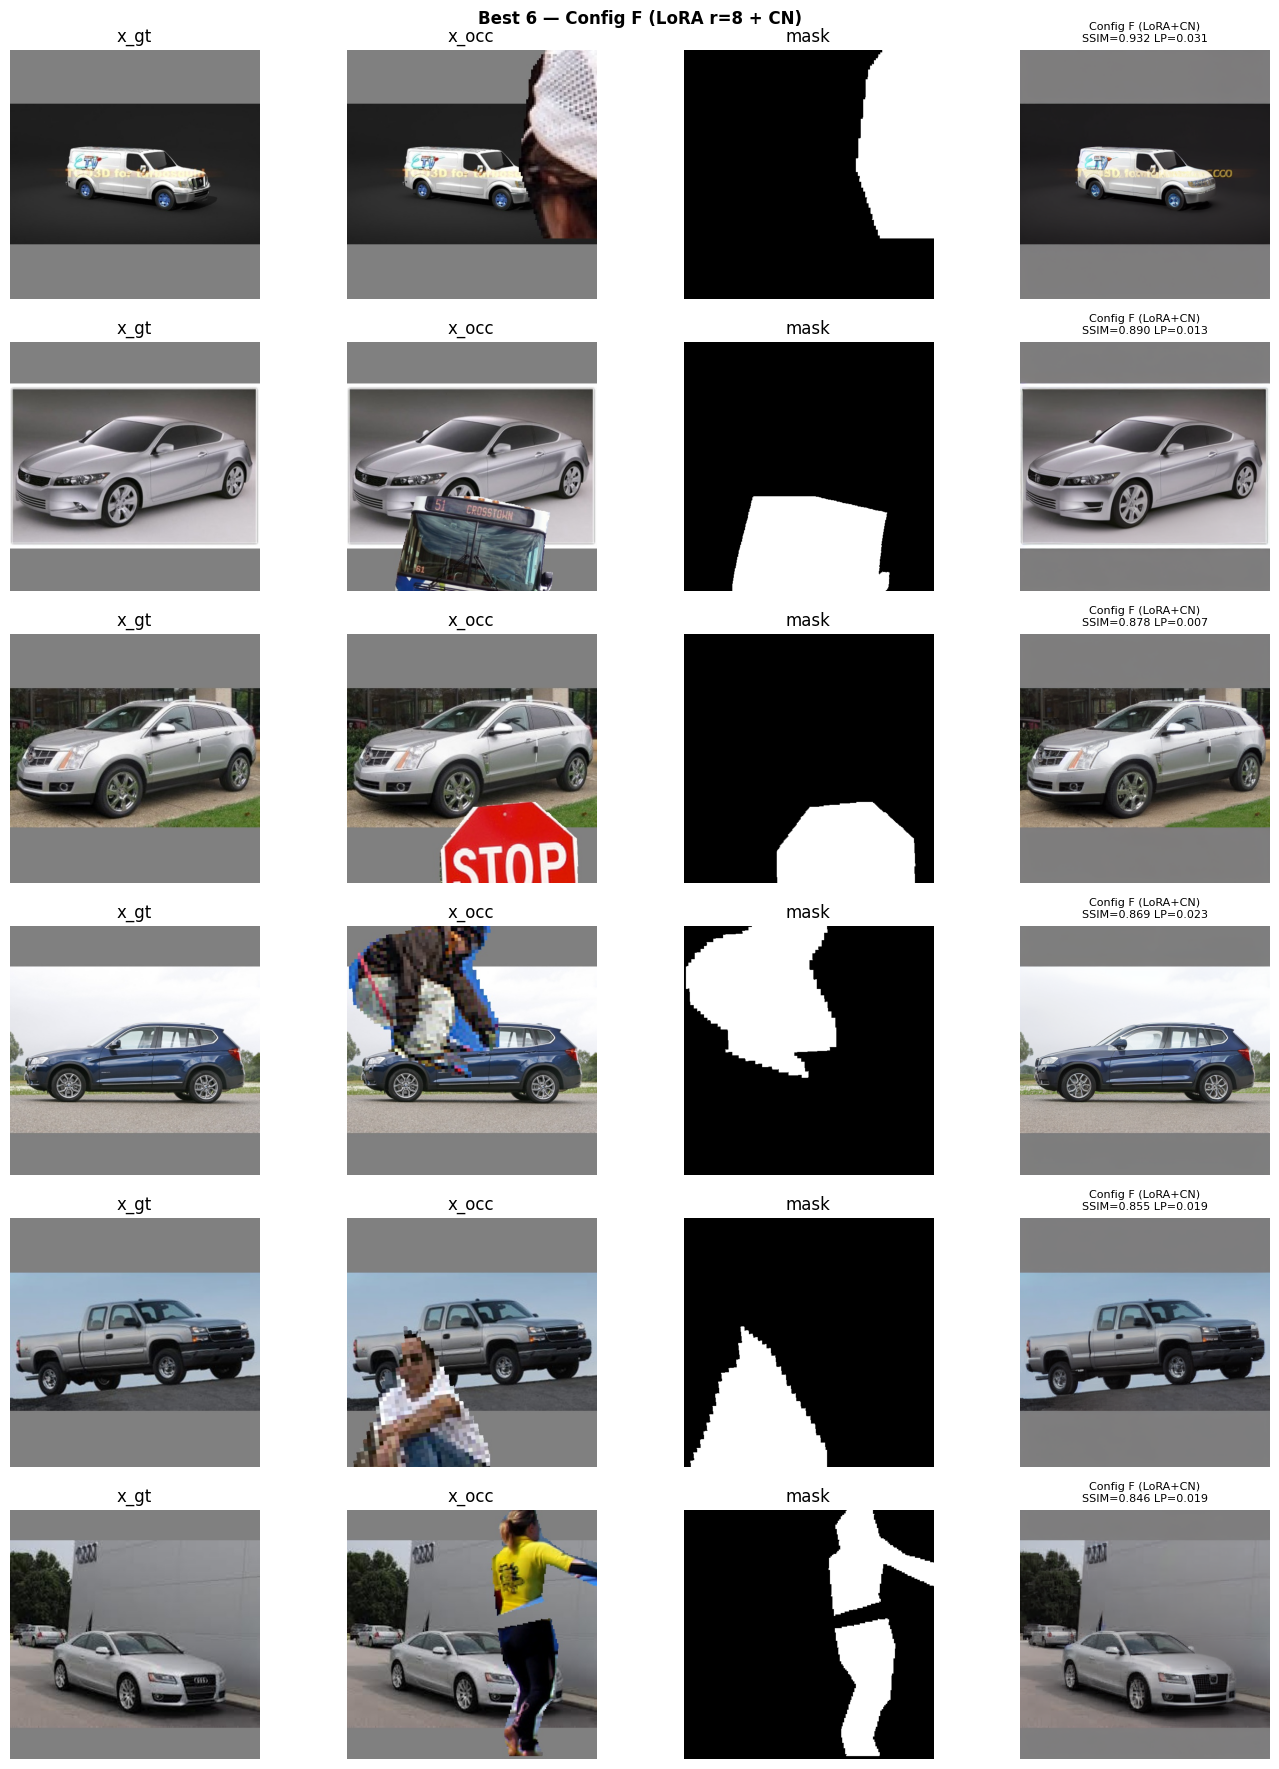

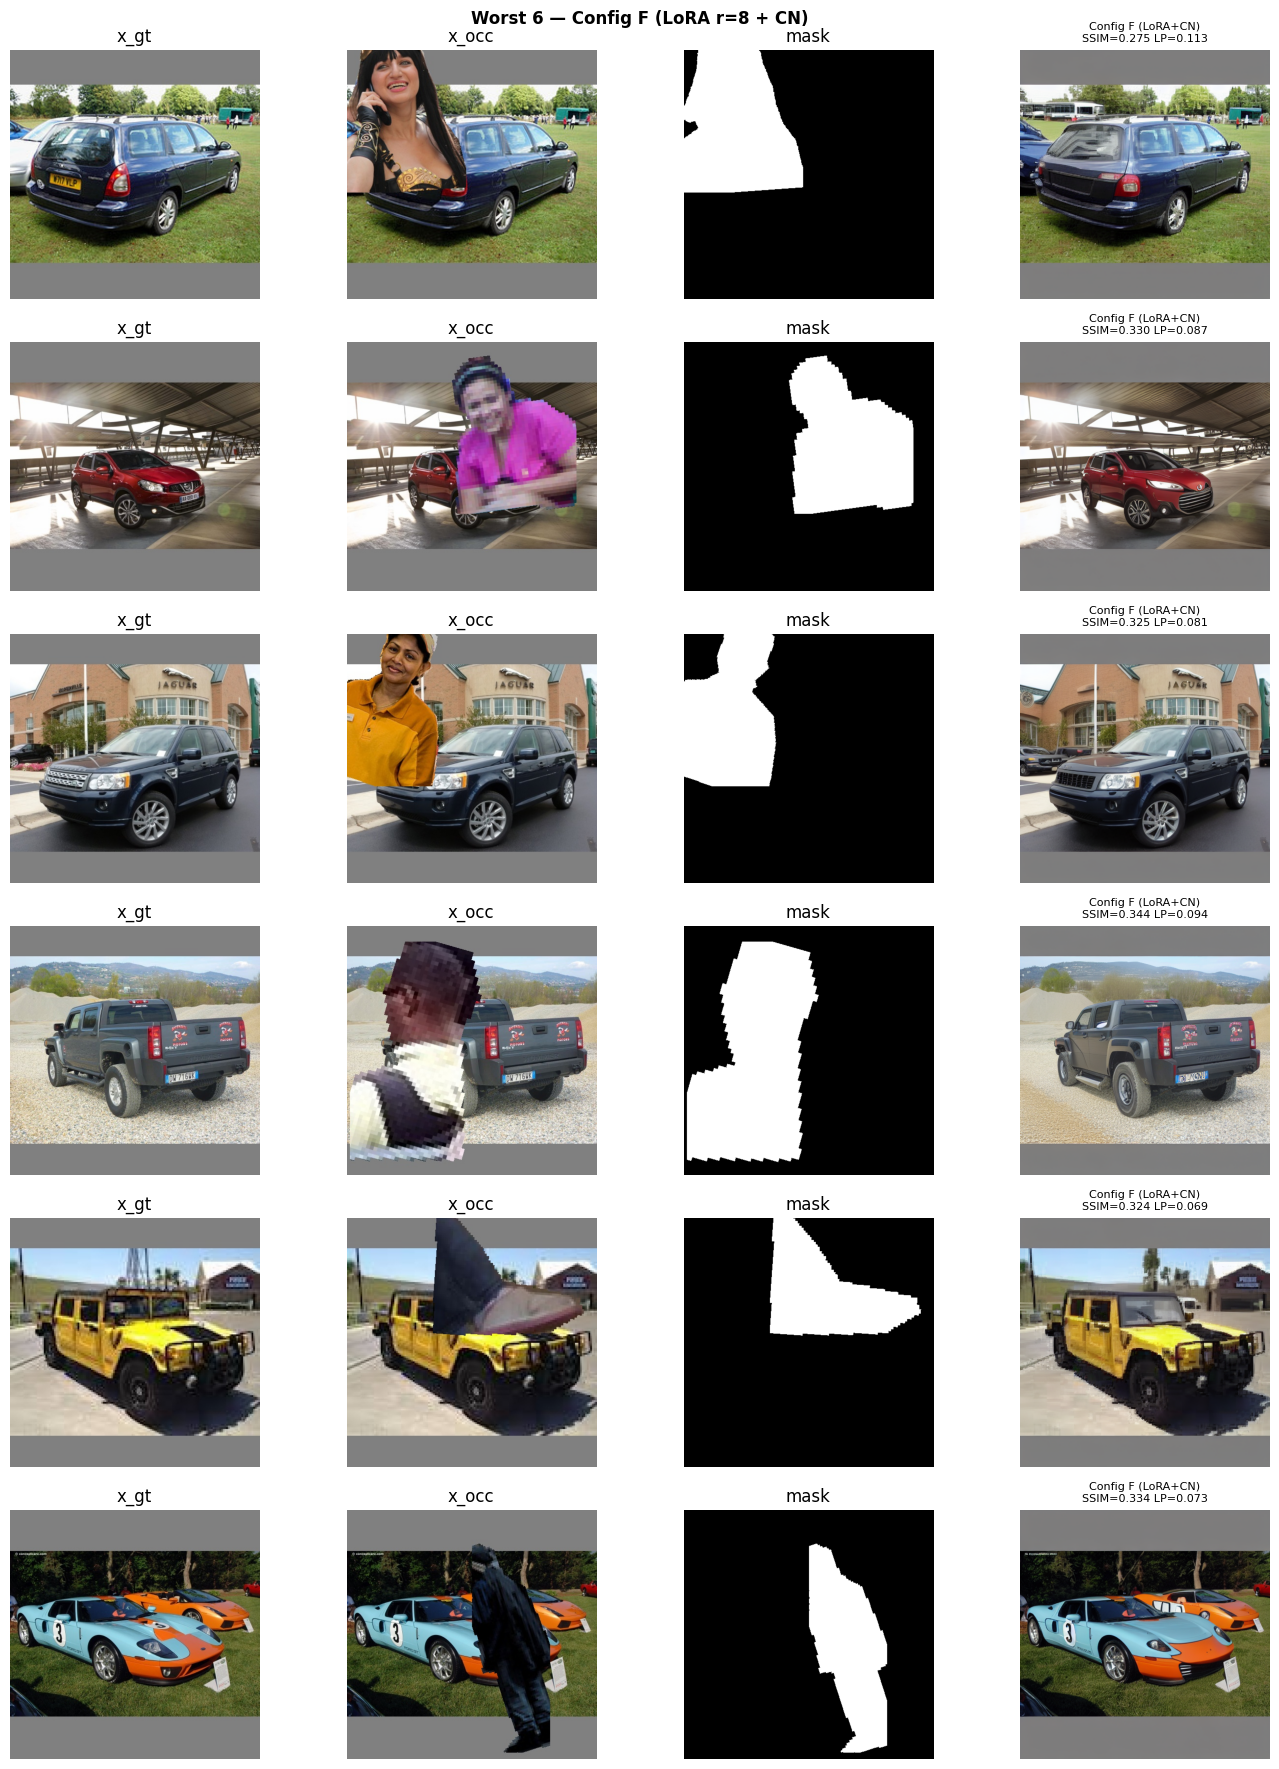

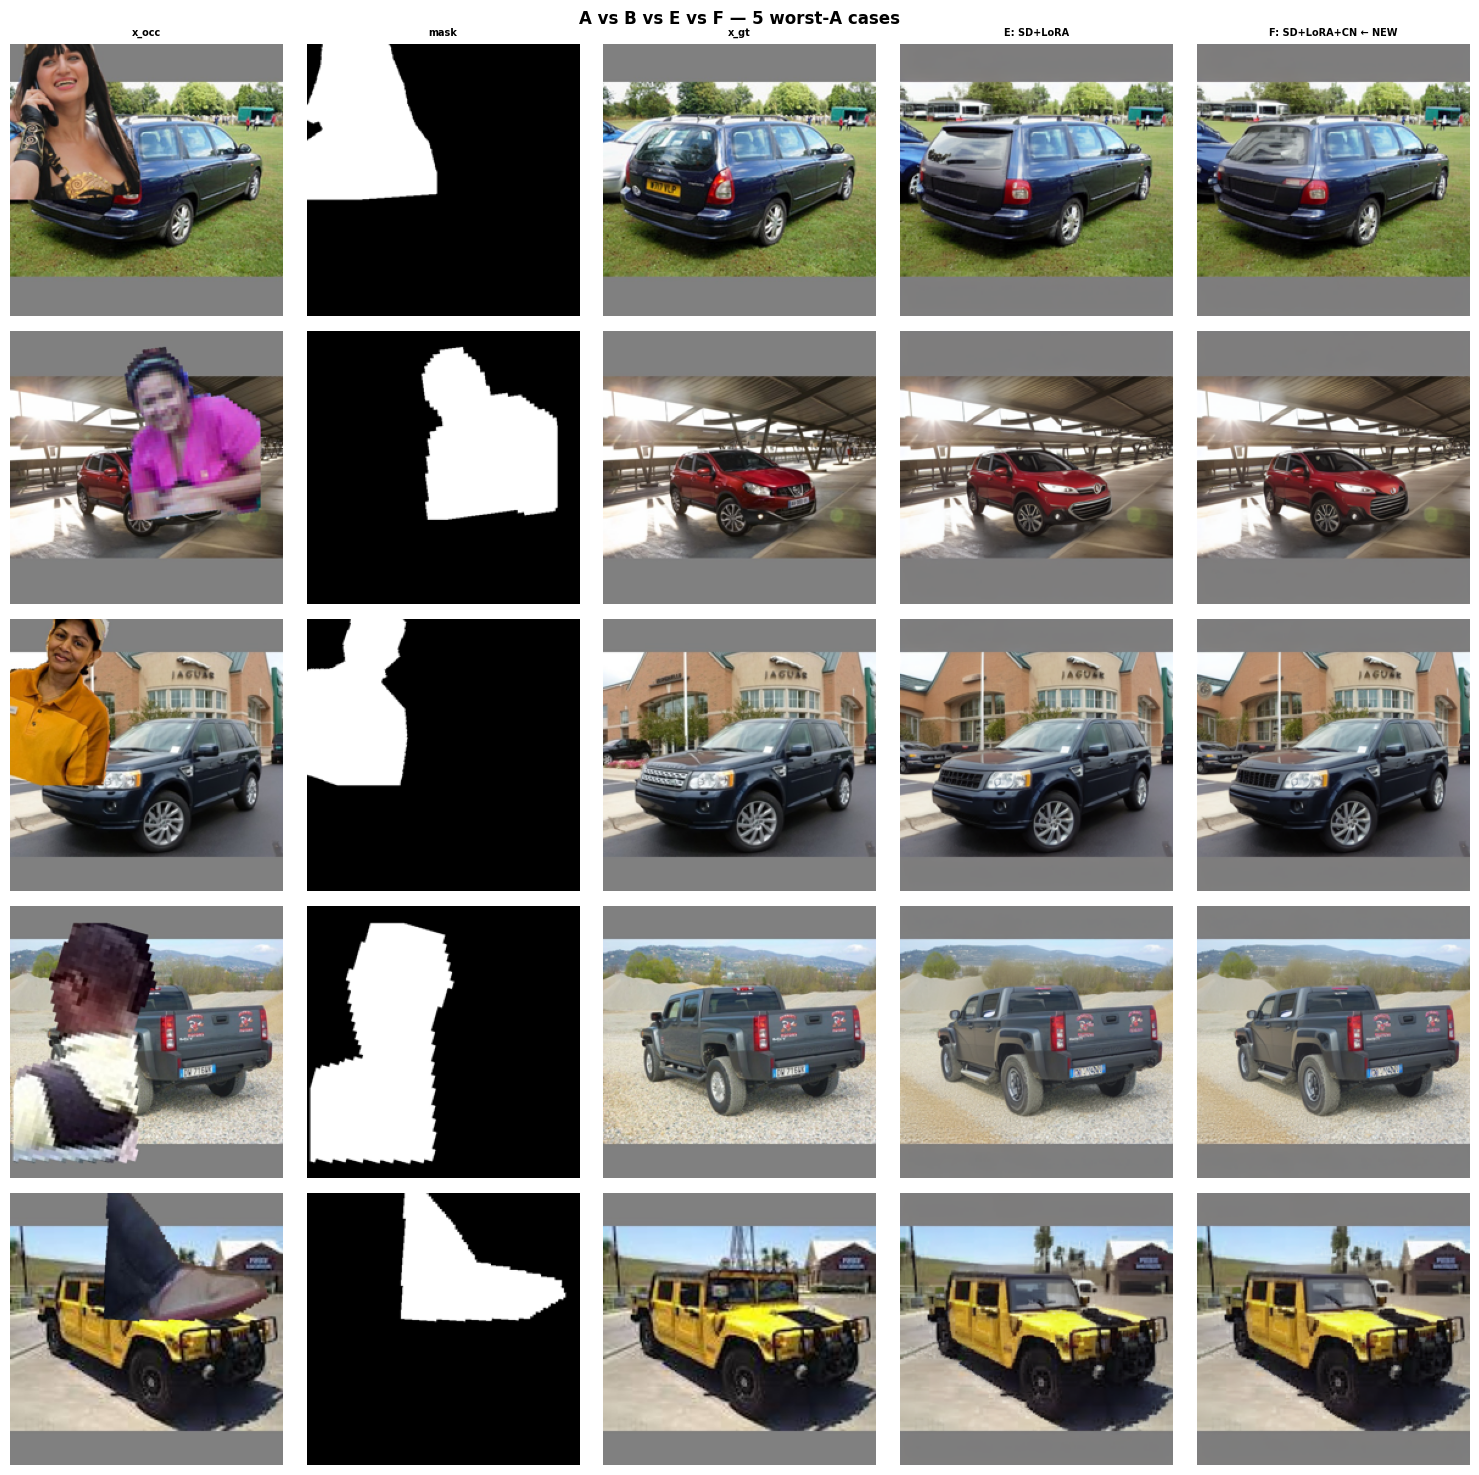

Saved: D:\CS331\DoAn\Occluded-Object-Restoration-CarsFocus\outputs\lora_sd_cn\reports/comparison_A_B_E_F.png


In [9]:
# CELL 9 — Visualize Best / Worst + Comparison A/B/E/F
import matplotlib.pyplot as plt

analysis_df = metric_df.copy()
analysis_df["score"] = analysis_df["ssim"] - analysis_df["lpips"]
best20  = analysis_df.sort_values("score", ascending=False).head(20)
worst20 = analysis_df.sort_values("score", ascending=True).head(20)
best20.to_csv(REPORT_DIR / "best20_cases.csv",  index=False)
worst20.to_csv(REPORT_DIR / "worst20_cases.csv", index=False)


def show_cases(case_df, title, n=6):
    n = min(n, len(case_df))
    fig, axes = plt.subplots(n, 4, figsize=(14, 3*n))
    if n == 1: axes = np.expand_dims(axes, 0)
    for i, (_, row) in enumerate(case_df.head(n).iterrows()):
        stem = row["stem"]
        rr   = pred_df[pred_df["stem"]==stem].iloc[0]
        gt   = Image.open(EVAL_GT_DIR   / f"{stem}.png").convert("RGB")
        pr   = Image.open(EVAL_PRED_DIR / f"{stem}.png").convert("RGB")
        occ  = Image.open(OCC_DIR / rr["x_occ"]).convert("RGB")
        msk  = Image.open(MASK_DIR / f"{stem}.png").convert("L")
        axes[i,0].imshow(gt);               axes[i,0].set_title("x_gt")
        axes[i,1].imshow(occ);              axes[i,1].set_title("x_occ")
        axes[i,2].imshow(msk, cmap="gray"); axes[i,2].set_title("mask")
        axes[i,3].imshow(pr);               axes[i,3].set_title(
            f"Config F (LoRA+CN)\nSSIM={row['ssim']:.3f} LP={row['lpips']:.3f}", fontsize=8)
        for ax in axes[i]: ax.axis("off")
    plt.suptitle(title, fontsize=12, fontweight="bold")
    plt.tight_layout(); plt.show()


show_cases(best20,  f"Best 6 — Config F (LoRA r={lora_rank} + CN)")
show_cases(worst20, f"Worst 6 — Config F (LoRA r={lora_rank} + CN)")

# Comparison A / B / E / F
a_csv = PROJECT_ROOT / "outputs" / "eval" / "metrics_per_image_A_SD_only.csv"
compare_stems = (
    pd.read_csv(a_csv).sort_values("ssim")["stem"].iloc[:5].tolist()
    if a_csv.exists() else worst20["stem"].iloc[:5].tolist()
)
configs = [
    (XHAT_A,  "A: SD only"),
    (XHAT_B,  "B: SD+CN"),
    (XHAT_E,  "E: SD+LoRA"),
    (PRED_DIR, f"F: SD+LoRA+CN ← NEW"),
]
avail  = [(d, lbl) for d, lbl in configs if d.exists() or d == PRED_DIR]
n_cols = 3 + len(avail)
fig, axes = plt.subplots(len(compare_stems), n_cols,
                         figsize=(3.0*n_cols, 3.0*len(compare_stems)))
fig.suptitle("A vs B vs E vs F — 5 worst-A cases", fontsize=12, fontweight="bold")
if len(compare_stems) == 1: axes = np.expand_dims(axes, 0)
col_titles = ["x_occ", "mask", "x_gt"] + [lbl for _, lbl in avail]

for ri, stem in enumerate(compare_stems):
    m_row = meta[meta["stem"]==stem]
    if len(m_row) == 0: continue
    m_row = m_row.iloc[0]
    imgs = [
        np.array(Image.open(OCC_DIR  / m_row["x_occ"]).convert("RGB").resize((224,224))),
        np.array(Image.open(MASK_DIR / f"{stem}.png").convert("L").resize((224,224))),
        np.array(Image.open(GT_DIR   / m_row["x_gt"]).convert("RGB").resize((224,224))),
    ]
    for d, _ in avail:
        p = d / f"{stem}.png"
        imgs.append(np.array(Image.open(p).convert("RGB").resize((224,224))) if p.exists() else None)
    for ci, (img, title) in enumerate(zip(imgs, col_titles)):
        ax = axes[ri, ci]
        ax.imshow(img, cmap="gray" if ci==1 else None) if img is not None \
            else ax.text(0.5, 0.5, "N/A", ha="center", va="center", transform=ax.transAxes, color="gray")
        ax.axis("off")
        if ri == 0: ax.set_title(title, fontsize=7, fontweight="bold")
    e_row = metric_df[metric_df["stem"]==stem]
    if len(e_row) > 0:
        axes[ri, n_cols-1].set_xlabel(
            f"SSIM={e_row['ssim'].values[0]:.3f}  LP={e_row['lpips'].values[0]:.3f}", fontsize=7)

plt.tight_layout()
plt.savefig(REPORT_DIR / "comparison_A_B_E_F.png", dpi=130, bbox_inches="tight")
plt.show()
print(f"Saved: {REPORT_DIR}/comparison_A_B_E_F.png")

In [10]:
# CELL 10 — GPU Report + Final Summary
import subprocess
if torch.cuda.is_available():
    peak = torch.cuda.max_memory_allocated() / 1024**2
    print(f"Peak VRAM: {peak:.0f} MiB ({peak/1024:.2f} GiB)")
    try:
        print(subprocess.check_output(
            ["nvidia-smi", "--query-gpu=name,memory.total,memory.used,memory.free",
             "--format=csv,noheader,nounits"], stderr=subprocess.DEVNULL
        ).decode().strip())
    except Exception: pass

print(f"\nNotebook 09 complete — Config F (SD + LoRA r={lora_rank} + CN)")
print(f"  SSIM  mean   : {summary['ssim_mean']:.4f}")
print(f"  LPIPS mean   : {summary['lpips_mean']:.4f}")
print(f"  FID          : {summary['fid']:.2f}")
print(f"  cn_scale     : {BEST_CN}")
print(f"  Inference    : {infer_elapsed/60:.1f} min")
print()
print("→ Tiếp theo: chạy 10_lora-inference-G.ipynb (LoRA + CN + IP)")

Peak VRAM: 3685 MiB (3.60 GiB)
NVIDIA GeForce RTX 4050 Laptop GPU, 6141, 4056, 1866

Notebook 09 complete — Config F (SD + LoRA r=8 + CN)
  SSIM  mean   : 0.5955
  LPIPS mean   : 0.0564
  FID          : 21.74
  cn_scale     : 0.25
  Inference    : 23.3 min

→ Tiếp theo: chạy 10_lora-inference-G.ipynb (LoRA + CN + IP)
